In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
import pandas as pd
import numpy

In [2]:
data=pd.read_csv('Churn_Modelling.csv')
data.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
data=data.drop(columns=['RowNumber','CustomerId','Surname'])


In [4]:
data.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [6]:
data.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [21]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import layers,Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

In [8]:
Oh=OneHotEncoder(sparse_output=False)

In [9]:
geo_encoded = Oh.fit_transform(data[['Geography']])
geo_df = pd.DataFrame(geo_encoded, columns=Oh.get_feature_names_out(['Geography']))
data = pd.concat([data.drop('Geography', axis=1), geo_df], axis=1)
gen_encoded = Oh.fit_transform(data[['Gender']])
gen_df = pd.DataFrame(gen_encoded, columns=Oh.get_feature_names_out(['Gender']))
data = pd.concat([data.drop('Gender', axis=1), gen_df], axis=1)

In [10]:
Standerd=StandardScaler()


In [11]:
data

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0,0.0,1.0
9996,516,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0,0.0,1.0
9997,709,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0,1.0,0.0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0,0.0,1.0


In [12]:
X_data=data.drop('Exited',axis=1)
y=data[['Exited']]

In [13]:
X=Standerd.fit_transform(X_data)

In [14]:
X

array([[-0.32622142,  0.29351742, -1.04175968, ..., -0.57380915,
         1.09598752, -1.09598752],
       [-0.44003595,  0.19816383, -1.38753759, ...,  1.74273971,
         1.09598752, -1.09598752],
       [-1.53679418,  0.29351742,  1.03290776, ..., -0.57380915,
         1.09598752, -1.09598752],
       ...,
       [ 0.60498839, -0.27860412,  0.68712986, ..., -0.57380915,
         1.09598752, -1.09598752],
       [ 1.25683526,  0.29351742, -0.69598177, ..., -0.57380915,
        -0.91241915,  0.91241915],
       [ 1.46377078, -1.04143285, -0.35020386, ..., -0.57380915,
         1.09598752, -1.09598752]], shape=(10000, 13))

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [155]:
from tensorflow.keras.optimizers import RMSprop
model=Sequential([
    Dense(512,activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(256,activation='relu'),
    Dropout(0.3),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(28,activation='relu'),
    Dense(10,activation='relu'),
    Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


c:\Users\Master\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [156]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [157]:
history = model.fit(X_train, y_train,
                    epochs=20, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop])

Epoch 1/20


250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8114 - loss: 0.4407 - val_accuracy: 0.8540 - val_loss: 0.3622
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8430 - loss: 0.3783 - val_accuracy: 0.8640 - val_loss: 0.3443
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8503 - loss: 0.3645 - val_accuracy: 0.8595 - val_loss: 0.3487
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8568 - loss: 0.3565 - val_accuracy: 0.8515 - val_loss: 0.3629
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8589 - loss: 0.3512 - val_accuracy: 0.8635 - val_loss: 0.3590
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8599 - loss: 0.3469 - val_accuracy: 0.8590 - val_loss: 0.3431
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8587 - loss: 0.3452 - val_accuracy: 0.8600 - val_loss: 0.3441
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8611 - loss: 0.3401 - val_accuracy: 0.8620 - val

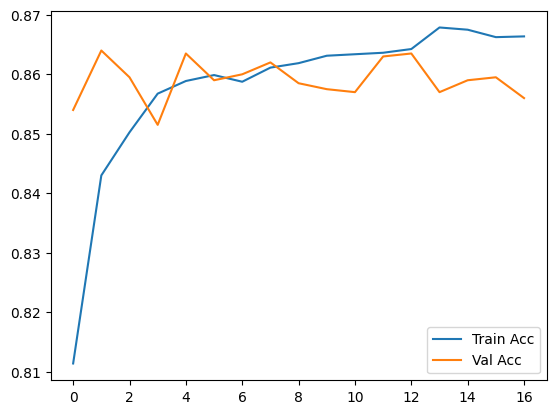

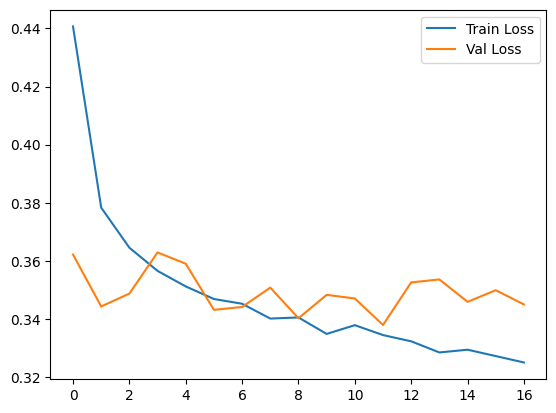

In [158]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


In [188]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
y_pred = (model.predict(X_test) > 0.3).astype("int32")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('accuracy_score',accuracy_score(y_test,y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[1416  191]
 [ 121  272]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1607
           1       0.59      0.69      0.64       393

    accuracy                           0.84      2000
   macro avg       0.75      0.79      0.77      2000
weighted avg       0.86      0.84      0.85      2000

accuracy_score 0.844


In [185]:
unseen_data = [
    [-0.326221, 0.293517, -1.041760, -1.225848, -0.911583, 0.646092, 0.970243, 0.021886, 0.997204, -0.578736, -0.573809, 1.095988, -1.095988],
    [-0.440036, 0.198164, -1.387538, 0.117350, -0.911583, -1.547768, 0.970243, 0.216534, -1.002804, -0.578736, 1.742740, 1.095988, -1.095988],
    [1.463771,-1.041433,-0.350204,0.859965,-0.911583,0.646092,-1.030670,-1.076370,0.997204,-0.578736,-0.573809,1.095988	,-1.095988]
]
# Convert to numpy array with correct dtype
X_unseen = np.array(unseen_data, dtype="float32")

# Predict probabilities
y_pred_proba = model.predict(X_unseen)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [186]:
y_pred_new = (y_pred_proba > 0.3).astype(int)

In [187]:
y_pred_new

array([[1],
       [0],
       [0]])